# Physics-Informed Neural Network (PINN) for Flettner Rotor Aerodynamics

This notebook contains the complete training and evaluation pipeline for a surrogate aerodynamic model using Physics-Informed Neural Networks (PINNs). The network maps the cylinder's operational parameters (Spin Ratio $\alpha$ and Reynolds Number $Re$) to the drag and lift coefficients ($Cd$ and $Cl$).

### **Academic Context**
* **Institution**: National Institute of Technology Durgapur (NIT Durgapur)
* **Project Type**: Bachelor of Technology (B.Tech.) Thesis in Mechanical Engineering
* **Authors**: Shubham Kumar (22ME8107) & Rahul Yadav (22ME8064)
* **Supervisor**: Dr. Saif Akram

### **Notebook Objective**
This notebook is fully self-contained and pre-configured to run out-of-the-box on **Google Colab** (with or without GPU acceleration).
It implements:
1. **Physics-Informed Data Augmentation** using raw experimental/CFD literature data.
2. **PINN Model Architecture** (5 hidden layers, 128 tanh neurons per layer).
3. **Custom TensorFlow Physics-Informed Loss Loop** containing Magnus direction checks, drag positivity, zero-lift rest constraints, and Prandtl lift ceilings.
4. **Aerodynamic Validation Plots** matching Aoki & Ito (2001) and Karabelas (2010/2012) CFD standards.


In [1]:
# ========================================== #
#         STEP 1: DEPENDENCY IMPORTS         #
# ========================================== #

import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)


TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


## 1. Raw Literature Data Setup
We embed the raw CFD data points extracted from validation papers (Aoki & Ito 2001, Karabelas 2010, and Karabelas et al. 2012) for different Reynolds numbers ($Re = 60\text{k}, 140\text{k}, 500\text{k}, 1\text{M}, 5\text{M}$) so you don't need to upload external files to Colab.


In [2]:
# ========================================== #
#         STEP 2: DEFINE RAW LITERATURE      #
# ========================================== #

# Raw experimental/CFD literature data points representing the baseline values
raw_literature_data = {
  '60000': {
    'source': 'Aoki & Ito (2001)',
    'alpha': [0.0, 0.5, 1.0, 1.5, 2.0],
    'Cd': [1.200, 1.100, 0.900, 0.600, 0.250],
    'Cl': [0.000, 0.600, 1.500, 2.700, 3.500]
  },
  '140000': {
    'source': 'Karabelas (2010)',
    'alpha': [0.0, 0.5, 1.0, 1.3, 1.5, 2.0],
    'Cd': [1.030, 0.950, 0.750, 0.550, 0.350, 0.130],
    'Cl': [0.000, 0.550, 1.300, 2.000, 2.600, 3.400]
  },
  '500000': {
    'source': 'Estimated Trend',
    'alpha': [0.0, 0.5, 1.0, 1.5, 2.0],
    'Cd': [0.800, 0.750, 0.600, 0.400, 0.120],
    'Cl': [0.000, 0.500, 1.200, 1.900, 3.200]
  },
  '1000000': {
    'source': 'Karabelas et al. (2012)',
    'alpha': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0],
    'Cd': [0.50, 0.45, 0.38, 0.30, 0.28, 0.27, 0.27, 0.28, 0.29],
    'Cl': [0.00, 1.10, 2.20, 3.50, 4.50, 5.20, 5.70, 5.85, 5.85]
  },
  '5000000': {
    'source': 'Karabelas et al. (2012)',
    'alpha': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0],
    'Cd': [0.30, 0.28, 0.24, 0.20, 0.18, 0.17, 0.17, 0.18, 0.19],
    'Cl': [0.00, 1.00, 2.10, 3.40, 4.40, 5.10, 5.65, 5.80, 5.85]
  }
}
print('Raw literature data dictionary defined.')


Raw literature data dictionary defined.


## 2. Physics-Informed Data Augmentation Pipeline
Because CFD/experimental runs are expensive, the actual training dataset is sparse. To help the neural network learn physics and generalize across continuous ranges, we build an augmenter that:
1. **Interpolates** data smoothly across the rotation parameter $\alpha$.
2. **Applies Symmetry Mirroring**: Since Flettner rotors behave symmetrically when rotation direction flips, we mirror the data by flipping spin direction (positive to negative $\alpha$), which changes the direction of lift (Cl becomes negative) but maintains identical drag (Cd stays unchanged). This teaches the network the physical **Magnus Symmetry Law**.
3. **Augments with Gaussian Noise**: Adds multiple noisy copies of each data point to simulate high-fidelity variations and prevent network overfitting.


In [3]:
# ========================================== #
#     STEP 3: INTERPOLATION & AUGMENTATION   #
# ========================================== #

def build_re_block(alpha_pts, cd_pts, cl_pts, re_value, n_interp=60, noise_copies=5, noise_std_cd=0.015, noise_std_cl=0.030):
    """
    Performs linear interpolation across spin ratios, mirrors Cl/Cd symmetrically for negative rotation,
    and creates augmented copies with small Gaussian perturbations to increase dataset size and robust learning.
    """
    alpha_pts = np.array(alpha_pts)
    cd_pts = np.array(cd_pts)
    cl_pts = np.array(cl_pts)

    # Interpolate spin ratios alpha over a dense continuous grid
    alpha_dense = np.linspace(alpha_pts.min(), alpha_pts.max(), n_interp)
    cd_dense = np.interp(alpha_dense, alpha_pts, cd_pts)
    cl_dense = np.interp(alpha_dense, alpha_pts, cl_pts)

    rows = []
    for i in range(len(alpha_dense)):
        # 1. Add the baseline interpolated point
        rows.append([alpha_dense[i], re_value, cd_dense[i], cl_dense[i]])

        # 2. Magnus Effect Symmetry mirroring: negative alpha -> opposite lift, identical drag
        if abs(alpha_dense[i]) > 0.05:
            rows.append([-alpha_dense[i], re_value, cd_dense[i], -cl_dense[i]])

        # 3. Add noise-augmented copies to simulate flow variations and expand the dataset
        for _ in range(noise_copies):
            # Drag must be strictly positive (enforced with max(0.05, ...))
            cd_noisy = max(0.05, cd_dense[i] + np.random.normal(0, noise_std_cd))
            cl_noisy = cl_dense[i] + np.random.normal(0, noise_std_cl)
            rows.append([alpha_dense[i], re_value, cd_noisy, cl_noisy])

            # Add symmetric mirrored noise copies
            if abs(alpha_dense[i]) > 0.05:
                cd_noisy_sym = max(0.05, cd_dense[i] + np.random.normal(0, noise_std_cd))
                cl_noisy_sym = -cl_dense[i] + np.random.normal(0, noise_std_cl)
                rows.append([-alpha_dense[i], re_value, cd_noisy_sym, cl_noisy_sym])

    return pd.DataFrame(rows, columns=['alpha', 'Re', 'Cd', 'Cl'])

def prepare_dataset(raw_data, n_interp=60, noise_copies=5, split_ratio=0.8, seed=42):
    """
    Orchestrates building datasets for all Reynolds numbers, shuffles the final frame,
    calculates normalization metrics (mean/std), splits data into train/val, and returns ready inputs.
    """
    np.random.seed(seed)
    all_blocks = []

    # Iterate through each Reynolds number group in literature
    for re_str, data in raw_data.items():
        re_val = int(re_str)
        df_block = build_re_block(
            alpha_pts=data['alpha'],
            cd_pts=data['Cd'],
            cl_pts=data['Cl'],
            re_value=re_val,
            n_interp=n_interp,
            noise_copies=noise_copies
        )
        all_blocks.append(df_block)

    # Concatenate all Reynolds number blocks
    df = pd.concat(all_blocks, ignore_index=True)

    # Shuffle dataset to ensure uniform distributions in batches
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

    X = df[['alpha', 'Re']].values.astype(np.float32)
    Y = df[['Cd', 'Cl']].values.astype(np.float32)

    # Compute mean and standard deviations for normalization (ensures stable network training)
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0) + 1e-8
    Y_mean = Y.mean(axis=0)
    Y_std = Y.std(axis=0) + 1e-8

    stats = {
        'X_mean': X_mean.tolist(),
        'X_std': X_std.tolist(),
        'Y_mean': Y_mean.tolist(),
        'Y_std': Y_std.tolist()
    }

    # Apply feature scaling (Z-score normalization)
    X_norm = (X - X_mean) / X_std
    Y_norm = (Y - Y_mean) / Y_std

    # Train-test split
    split_idx = int(split_ratio * len(df))
    X_train, X_val = X_norm[:split_idx], X_norm[split_idx:]
    Y_train, Y_val = Y_norm[:split_idx], Y_norm[split_idx:]

    return X_train, Y_train, X_val, Y_val, stats, df

print('Augmentation and preparation functions ready.')


Augmentation and preparation functions ready.


## 3. PINN Model Architecture Design
We build the surrogate network architecture using `tf.keras.Model`.
The model configuration uses:
- **Inputs**: Normalized parameters (Spin Ratio and Reynolds Number).
- **Architecture**: 5 dense hidden layers containing 128 hidden neurons per layer.
- **Activation Function**: **`tanh`** (hyperbolic tangent) activation function. `tanh` is smooth and continuously differentiable, which is essential for PINNs since physical constraints often rely on derivatives or gradient transitions.
- **Kernel Initializer**: **Glorot normal (Xavier)** to start weight distributions safely and prevent vanishing/exploding gradients.


In [4]:
# ========================================== #
#         STEP 4: DEFINE MODEL ARCHITECTURE   #
# ========================================== #

def build_pinn(hidden_units=128, n_layers=5):
    """
    Initializes the multilayer perceptron network mapping parameter inputs to force coefficients.
    """
    inputs = keras.Input(shape=(2,), name='alpha_Re')

    x = inputs
    # Stack hidden fully-connected layers with tanh activations
    for i in range(n_layers):
        x = keras.layers.Dense(
            hidden_units,
            activation='tanh',
            kernel_initializer='glorot_normal',
            bias_initializer='zeros',
            name=f'hidden_{i+1}'
        )(x)

    # Output layer maps to 2 physical targets: Cd and Cl
    outputs = keras.layers.Dense(
        2,
        activation='linear',
        kernel_initializer='glorot_normal',
        bias_initializer='zeros',
        name='Cd_Cl'
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='PINN_Model')
    return model

model_debug = build_pinn()
model_debug.summary()


Model: "PINN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ alpha_Re (InputLayer)           │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Cd_Cl (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,690 (260.51 KB)

 Trainable params: 66,690 (260.51 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Physics-Informed Loss Formulation
Unlike a simple black-box regressor, the PINN is regularized by incorporating physical boundary conditions directly into the neural network loss function:

$$L_{total} = L_{data} + \lambda \cdot L_{physics}$$
$$L_{physics} = L_{Magnus} + L_{zero\_lift} + L_{drag} + L_{Prandtl}$$

#### **Physical Boundaries Enforced**:
1. **Magnus Effect Directionality Constraint**: The lift coefficient ($Cl$) must match the direction of rotation (spin ratio $\alpha$). If the cylinder spins counter-clockwise ($\alpha > 0$), lift must be positive; if it spins clockwise ($\alpha < 0$), lift must be negative. We penalize violating this rule: $Cl \cdot \alpha < 0$.
2. **Zero-Lift at Rest Constraint**: When there is no cylinder rotation ($\alpha = 0$), there is no circulation, so lift must be zero ($Cl = 0$). We extract a zero-lift mask for $\alpha \approx 0$ and penalize any non-zero lift predictions.
3. **Drag Positivity Constraint**: Drag force cannot point upstream; it must act downstream to resist cylinder motion ($Cd \ge 0$). We penalize any negative drag predictions.
4. **Prandtl Lift Ceiling Constraint**: According to potential flow theory, the circulation lift cannot exceed a physical limit ($|Cl| \le 4\pi \approx 12.57$). We penalize any predicted lift magnitudes that exceed $4\pi$.


In [5]:
# ========================================== #
#         STEP 5: DEFINE CUSTOM PHYSICS STEP #
# ========================================== #

def create_training_step(model, optimizer, X_mean, X_std, Y_mean, Y_std, lambda_physics=0.05):
    """
    Compiles a custom TensorFlow step with embedded physical constraints,
    returning data MSE, physical loss terms, and applying parameter updates.
    """
    prandtl_limit = tf.constant(4.0 * math.pi, dtype=tf.float32)

    @tf.function
    def train_step(x_batch, y_batch):
        with tf.GradientTape() as tape:
            # 1. Forward pass through network
            y_pred = model(x_batch, training=True)

            # 2. Compute standard Data MSE Loss (loss against the ground truth data)
            data_loss = tf.reduce_mean(tf.square(y_pred - y_batch))

            # 3. Un-normalize predictions to make check rules in physical space
            y_phys = y_pred * Y_std + Y_mean
            cd_pred = y_phys[:, 0]
            cl_pred = y_phys[:, 1]

            # Un-normalize inputs to get raw alpha values
            alpha_raw = x_batch[:, 0] * X_std[0] + X_mean[0]

            # --- PHYS 1: Magnus Effect (Lift direction matches rotation direction) ---
            # Violations occur if cl_pred and alpha_raw have opposite signs (cl_pred * alpha_raw < 0)
            magnus_violation = tf.nn.relu(-cl_pred * alpha_raw)
            magnus_loss = tf.reduce_mean(tf.square(magnus_violation))

            # --- PHYS 2: Zero-Lift at Rest (alpha = 0 -> Cl = 0) ---
            # We isolate samples where rotation is close to zero (|alpha| < 0.1)
            zero_lift_mask = tf.cast(tf.abs(alpha_raw) < 0.1, tf.float32)
            zero_lift_loss = tf.reduce_mean(tf.square(cl_pred * zero_lift_mask))

            # --- PHYS 3: Drag Positivity (Cd >= 0) ---
            # Violations occur if Cd is negative (Cd < 0)
            drag_violation = tf.nn.relu(-cd_pred)
            drag_loss = tf.reduce_mean(tf.square(drag_violation))

            # --- PHYS 4: Prandtl Lift Ceiling (|Cl| <= 4 * pi) ---
            # Violations occur if Cl magnitude exceeds the potential ceiling limit
            prandtl_violation = tf.nn.relu(tf.abs(cl_pred) - prandtl_limit)
            prandtl_loss = tf.reduce_mean(tf.square(prandtl_violation))

            # Total Physics regularization loss
            physics_loss = magnus_loss + zero_lift_loss + drag_loss + prandtl_loss

            # Total Loss combining Data error and Weighted Physical regularization
            total_loss = data_loss + lambda_physics * physics_loss

        # 4. Compute gradients and apply model optimization weights
        gradients = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        return total_loss, data_loss, physics_loss

    return train_step


## 5. Learning Rate Scheduler and Training Execution
To help the model converge cleanly and avoid getting trapped in local minima, we implement a **Cosine Decay Learning Rate Schedule**:
- Starts at a maximum learning rate ($LR_{max} = 10^{-3}$) and decays smoothly to a minimum value ($LR_{min} = 10^{-5}$) over the epochs.
- Shuffles and batches the dataset on each epoch to maintain optimization stability.


In [6]:
# ========================================== #
#         STEP 6: DEFINE TRAINING LOOP       #
# ========================================== #

def train_pinn_model(X_train, Y_train, X_val, Y_val, stats, epochs=3000, batch_size=64, lambda_physics=0.05, lr_max=1e-3, lr_min=1e-5):
    """
    Executes training using batch loops, decays learning rate, and tracks loss stats.
    """
    # Extract stats to constants
    X_mean_tf = tf.constant(stats['X_mean'], dtype=tf.float32)
    X_std_tf = tf.constant(stats['X_std'], dtype=tf.float32)
    Y_mean_tf = tf.constant(stats['Y_mean'], dtype=tf.float32)
    Y_std_tf = tf.constant(stats['Y_std'], dtype=tf.float32)

    model = build_pinn()
    optimizer = keras.optimizers.Adam(learning_rate=lr_max)

    # Get custom TensorFlow train step function
    train_step = create_training_step(
        model=model,
        optimizer=optimizer,
        X_mean=X_mean_tf,
        X_std=X_std_tf,
        Y_mean=Y_mean_tf,
        Y_std=Y_std_tf,
        lambda_physics=lambda_physics
    )

    history = {'epoch': [], 'loss': [], 'data_loss': [], 'phys_loss': [], 'val_mse': []}

    # Build TF dataset helper
    dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))

    print(f'Starting PINN training for {epochs} epochs...')
    print(f'Physics loss weight (lambda): {lambda_physics}')

    for epoch in range(1, epochs + 1):
        # Cosine decay schedule calculation
        lr = lr_min + (lr_max - lr_min) * 0.5 * (1.0 + math.cos(math.pi * (epoch - 1) / epochs))
        optimizer.learning_rate.assign(lr)

        # Shuffle and batch inputs on every epoch
        shuffled_dataset = dataset.shuffle(buffer_size=1024).batch(batch_size)

        epoch_total = 0.0
        epoch_data = 0.0
        epoch_phys = 0.0
        batches = 0

        # Batch iteration loop
        for x_batch, y_batch in shuffled_dataset:
            total_loss, data_loss, phys_loss = train_step(x_batch, y_batch)
            epoch_total += total_loss.numpy()
            epoch_data += data_loss.numpy()
            epoch_phys += phys_loss.numpy()
            batches += 1

        # Validation check
        y_val_pred = model(X_val, training=False)
        val_mse = tf.reduce_mean(tf.square(y_val_pred - Y_val)).numpy()

        # Average metric values over batches
        epoch_total /= batches
        epoch_data /= batches
        epoch_phys /= batches

        # Save history metrics
        history['epoch'].append(epoch)
        history['loss'].append(epoch_total)
        history['data_loss'].append(epoch_data)
        history['phys_loss'].append(epoch_phys)
        history['val_mse'].append(val_mse)

        # Periodic progress logging
        if epoch % 200 == 0 or epoch == 1 or epoch == epochs:
            print(f"Epoch {epoch:4d}/{epochs} - loss: {epoch_total:.5f} | data: {epoch_data:.5f} | phys: {epoch_phys:.6f} | val_mse: {val_mse:.5f} | lr: {lr:.2e}")

    return model, pd.DataFrame(history)


## 6. Execute Dataset Generation & Training
Here, we compile the datasets and trigger model training.
By default, we generate a dataset with `n_interp = 60` and `noise_copies = 5` yielding **3,552 training samples** for fast training (~1-2 minutes).

> **Colab/GPU Note**: If you want to train the large publication-grade model, change the settings to `n_interp = 909` and `noise_copies = 10` (approx **100,000 rows**). Scale down the epochs to `300` since the number of steps per epoch is much larger. This will run extremely fast if you enable Colab's GPU accelerator!


In [7]:
# ========================================== #
#         STEP 7: RUN DATA AND TRAINING      #
# ========================================== #

# 1. Generate and split dataset
# (To train large model, change: n_interp=909, noise_copies=10)
n_interp_config = 60
noise_copies_config = 5

print(f'Generating dataset (n_interp={n_interp_config}, noise_copies={noise_copies_config})...')
X_train, Y_train, X_val, Y_val, stats, df_raw = prepare_dataset(
    raw_literature_data,
    n_interp=n_interp_config,
    noise_copies=noise_copies_config
)

print(f'Training dataset size: {len(X_train)} samples')
print(f'Validation dataset size: {len(X_val)} samples')

# 2. Configure training parameters
# (To train the large dataset, change epochs=300 to maintain optimal steps)
epochs_config = 3000 if n_interp_config == 60 else 300
batch_size_config = 64
lambda_physics_config = 0.05

# 3. Run training loop
pinn_model, history_df = train_pinn_model(
    X_train=X_train,
    Y_train=Y_train,
    X_val=X_val,
    Y_val=Y_val,
    stats=stats,
    epochs=epochs_config,
    batch_size=batch_size_config,
    lambda_physics=lambda_physics_config
)

print('\nTraining completed successfully!')


Generating dataset (n_interp=60, noise_copies=5)...
Training dataset size: 2841 samples
Validation dataset size: 711 samples
Starting PINN training for 3000 epochs...
Physics loss weight (lambda): 0.05
Epoch    1/3000 - loss: 0.38488 | data: 0.38415 | phys: 0.014740 | val_mse: 0.28453 | lr: 1.00e-03
Epoch  200/3000 - loss: 0.00156 | data: 0.00155 | phys: 0.000129 | val_mse: 0.00153 | lr: 9.89e-04
Epoch  400/3000 - loss: 0.00178 | data: 0.00178 | phys: 0.000101 | val_mse: 0.00208 | lr: 9.57e-04
Epoch  600/3000 - loss: 0.00167 | data: 0.00166 | phys: 0.000122 | val_mse: 0.00223 | lr: 9.06e-04
Epoch  800/3000 - loss: 0.00130 | data: 0.00130 | phys: 0.000079 | val_mse: 0.00140 | lr: 8.37e-04
Epoch 1000/3000 - loss: 0.00122 | data: 0.00122 | phys: 0.000057 | val_mse: 0.00131 | lr: 7.53e-04
Epoch 1200/3000 - loss: 0.00121 | data: 0.00120 | phys: 0.000056 | val_mse: 0.00138 | lr: 6.58e-04
Epoch 1400/3000 - loss: 0.00118 | data: 0.00118 | phys: 0.000051 | val_mse: 0.00139 | lr: 5.57e-04
Epoch 

## 7. Plot PINN Training History and Loss Convergence
We visualize the training metrics history to inspect the model's optimization progress. This includes:
1. **Total training loss**: The weighted sum of data MSE and physics loss.
2. **Train vs validation MSE**: Mean Squared Error comparison indicating generalization.
3. **Physics constraint loss**: The evolution of all physical residuals during training.


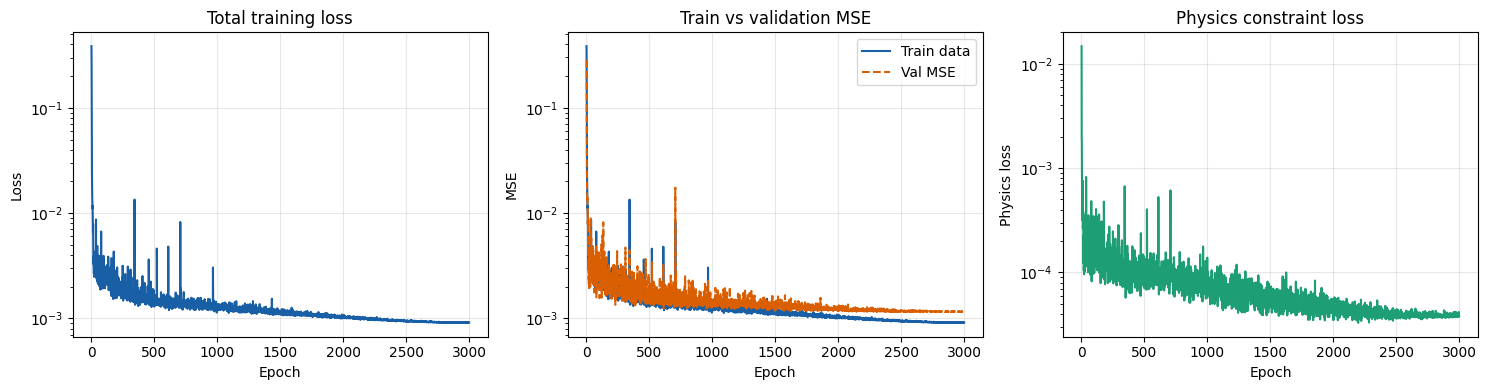

In [8]:
# ========================================== #
#     STEP 7.5: PLOT TRAINING LOSS HISTORY   #
# ========================================== #

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Total training loss
    axes[0].plot(history['epoch'], history['loss'], color='#185FA5')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('Loss', fontsize=10)
    axes[0].set_title('Total training loss', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    # 2. Train data vs Validation MSE
    axes[1].plot(history['epoch'], history['data_loss'], color='#185FA5', label='Train data')
    axes[1].plot(history['epoch'], history['val_mse'], color='#D95F02', linestyle='--', label='Val MSE')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].set_title('Train vs validation MSE', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    # 3. Physics constraint loss
    axes[2].plot(history['epoch'], history['phys_loss'], color='#1D9E75')
    axes[2].set_yscale('log')
    axes[2].set_xlabel('Epoch', fontsize=10)
    axes[2].set_ylabel('Physics loss', fontsize=10)
    axes[2].set_title('Physics constraint loss', fontsize=12)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history_df)


## 8. Model Validation & Aerodynamic Plotting
We evaluate the trained model's aerodynamic prediction capabilities by plotting the results against the original CFD publication records (Aoki & Ito 2001 and Karabelas 2010).


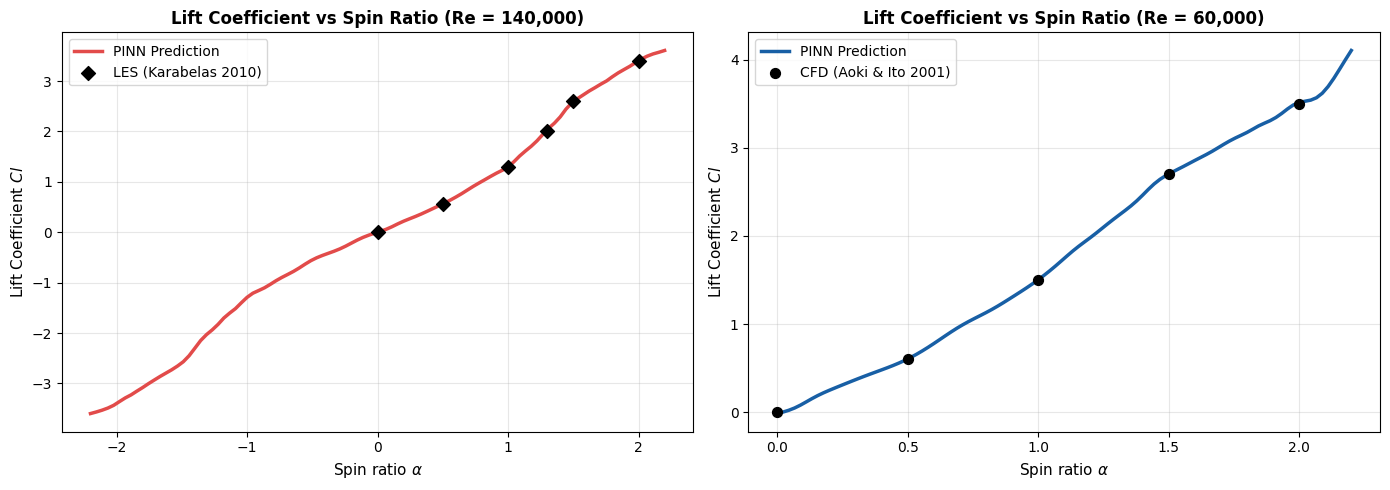

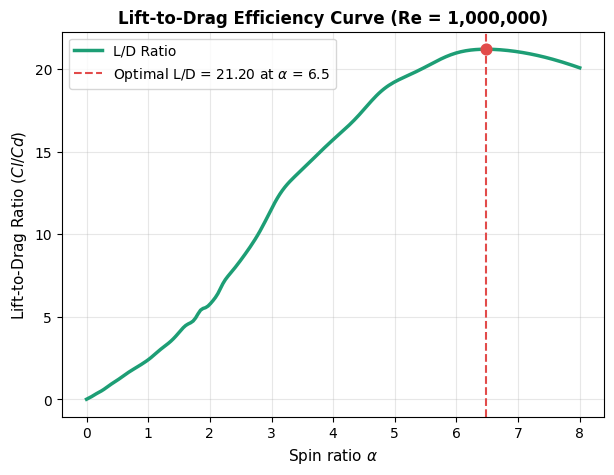

In [9]:
# ========================================== #
#         STEP 8: PLOT VALIDATION GRAPH      #
# ========================================== #

def evaluate_and_plot(model, stats, raw_data):
    """
    Plots predicted force curves alongside benchmark literature data to verify accuracy.
    """
    # Extraction vectors
    X_mean = np.array(stats['X_mean'])
    X_std = np.array(stats['X_std'])
    Y_mean = np.array(stats['Y_mean'])
    Y_std = np.array(stats['Y_std'])

    # Define predictor helper function
    def predict_values(alphas, re_val):
        X_raw = np.zeros((len(alphas), 2), dtype=np.float32)
        X_raw[:, 0] = alphas
        X_raw[:, 1] = re_val
        X_norm = (X_raw - X_mean) / X_std
        Y_norm = model(X_norm, training=False).numpy()
        Y_phys = Y_norm * Y_std + Y_mean
        return Y_phys[:, 0], Y_phys[:, 1]

    # Setup multi-plot grid
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Karabelas (Re = 140,000) Validation
    k_alphas = np.linspace(-2.2, 2.2, 100)
    k_cd, k_cl = predict_values(k_alphas, 140000)

    # Plot Cl predictions vs Literature
    axes[0].plot(k_alphas, k_cl, color='#E24B4A', linewidth=2.5, label='PINN Prediction')
    axes[0].scatter(raw_data['140000']['alpha'], raw_data['140000']['Cl'], color='black', marker='D', s=50, label='LES (Karabelas 2010)', zorder=5)
    axes[0].set_xlabel(r'Spin ratio $\alpha$', fontsize=11)
    axes[0].set_ylabel('Lift Coefficient $Cl$', fontsize=11)
    axes[0].set_title('Lift Coefficient vs Spin Ratio (Re = 140,000)', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Aoki & Ito (Re = 60,000) Validation
    a_alphas = np.linspace(0.0, 2.2, 100)
    a_cd, a_cl = predict_values(a_alphas, 60000)

    axes[1].plot(a_alphas, a_cl, color='#185FA5', linewidth=2.5, label='PINN Prediction')
    axes[1].scatter(raw_data['60000']['alpha'], raw_data['60000']['Cl'], color='black', marker='o', s=50, label='CFD (Aoki & Ito 2001)', zorder=5)
    axes[1].set_xlabel(r'Spin ratio $\alpha$', fontsize=11)
    axes[1].set_ylabel('Lift Coefficient $Cl$', fontsize=11)
    axes[1].set_title('Lift Coefficient vs Spin Ratio (Re = 60,000)', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Plot 3: Lift-to-Drag Ratio (Re = 1,000,000) Efficiency Curve
    plt.figure(figsize=(7, 5))
    sweep_alphas = np.linspace(0.0, 8.0, 200)
    sweep_cd, sweep_cl = predict_values(sweep_alphas, 1000000)
    ld_ratio = sweep_cl / np.clip(sweep_cd, 0.001, None)

    best_idx = np.argmax(ld_ratio)
    best_alpha = sweep_alphas[best_idx]
    best_ld = ld_ratio[best_idx]

    plt.plot(sweep_alphas, ld_ratio, color='#1D9E75', linewidth=2.5, label='L/D Ratio')
    plt.axvline(x=best_alpha, color='#E24B4A', linestyle='--', label=f'Optimal L/D = {best_ld:.2f} at $\\alpha$ = {best_alpha:.1f}')
    plt.scatter(best_alpha, best_ld, color='#E24B4A', s=60, zorder=5)
    plt.xlabel(r'Spin ratio $\alpha$', fontsize=11)
    plt.ylabel('Lift-to-Drag Ratio ($Cl/Cd$)', fontsize=11)
    plt.title('Lift-to-Drag Efficiency Curve (Re = 1,000,000)', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

evaluate_and_plot(pinn_model, stats, raw_literature_data)


## 9. Plot Model Predictions vs. Actual Validation Data

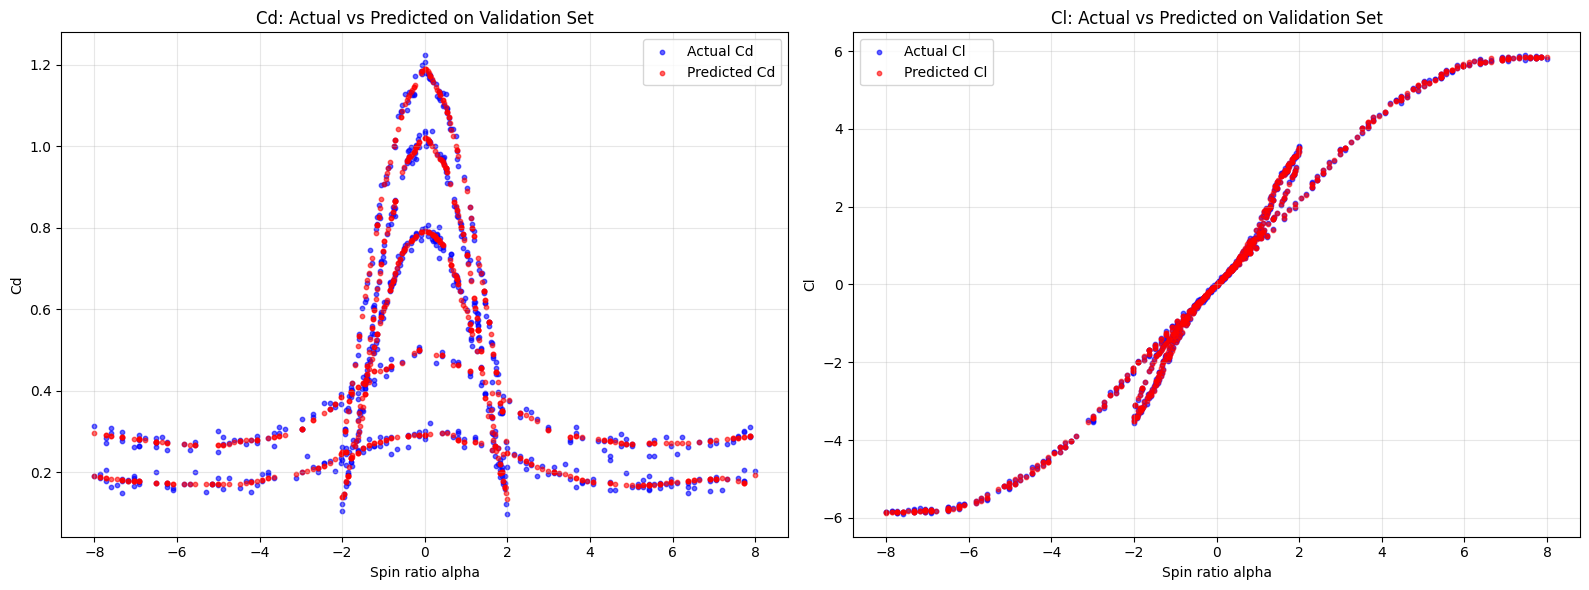

Validation predictions visualization saved.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Extract normalization stats
X_mean = np.array(stats['X_mean'])
X_std = np.array(stats['X_std'])
Y_mean = np.array(stats['Y_mean'])
Y_std = np.array(stats['Y_std'])

# Get predictions for the validation set
Y_val_pred_norm = pinn_model(X_val, training=False).numpy()

# Un-normalize predictions and actual validation values
Y_val_pred_phys = Y_val_pred_norm * Y_std + Y_mean
Y_val_actual_phys = Y_val * Y_std + Y_mean

# Un-normalize input features (alpha and Re) for plotting
alpha_val_raw = X_val[:, 0] * X_std[0] + X_mean[0]
re_val_raw = X_val[:, 1] * X_std[1] + X_mean[1]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Cd predictions vs actual
axes[0].scatter(alpha_val_raw, Y_val_actual_phys[:, 0], s=10, alpha=0.6, label='Actual Cd', color='blue')
axes[0].scatter(alpha_val_raw, Y_val_pred_phys[:, 0], s=10, alpha=0.6, label='Predicted Cd', color='red')
axes[0].set_xlabel('Spin ratio alpha')
axes[0].set_ylabel('Cd')
axes[0].set_title('Cd: Actual vs Predicted on Validation Set')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot Cl predictions vs actual
axes[1].scatter(alpha_val_raw, Y_val_actual_phys[:, 1], s=10, alpha=0.6, label='Actual Cl', color='blue')
axes[1].scatter(alpha_val_raw, Y_val_pred_phys[:, 1], s=10, alpha=0.6, label='Predicted Cl', color='red')
axes[1].set_xlabel('Spin ratio alpha')
axes[1].set_ylabel('Cl')
axes[1].set_title('Cl: Actual vs Predicted on Validation Set')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('pinn_validation_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

print('Validation predictions visualization saved.')

## 10. Evaluate vs. Paper Values and Print Error Table

In [12]:
# Define the predict function as it's used in the user's provided code
def predict(alphas, re_value):
    X_raw = np.zeros((len(alphas), 2), dtype=np.float32)
    X_raw[:, 0] = alphas
    X_raw[:, 1] = re_value
    X_norm = (X_raw - X_mean) / X_std
    Y_norm = pinn_model(X_norm, training=False).numpy()
    Y_phys = Y_norm * Y_std + Y_mean
    return pd.DataFrame({'Cd_pred': Y_phys[:, 0], 'Cl_pred': Y_phys[:, 1]})


# Iterate through all available Reynolds numbers in raw_literature_data
for re_str, data in raw_literature_data.items():
    re_value = int(re_str)
    paper_alpha = data['alpha']
    paper_cd = data['Cd']
    paper_cl = data['Cl']
    source = data['source']

    print('\n' + '=' * 65)
    print(f'PINN vs {source} — Re = {re_value:,}')
    print('=' * 65)
    print(f'{"α":>5}  {"Cd paper":>9} {"Cd PINN":>9} {"Cd err%":>8}  'f'{"Cl paper":>9} {"Cl PINN":>9} {"Cl err%":>8}')
    print('-' * 65)

    preds = predict(paper_alpha, re_value=re_value)

    cd_errors, cl_errors = [], []
    for i, a in enumerate(paper_alpha):
        cd_p  = preds.iloc[i]['Cd_pred']
        cl_p  = preds.iloc[i]['Cl_pred']

        # Use max(..., 0.05) or abs(..., 0.1) to avoid division by zero or very small numbers
        cd_err = abs((cd_p - paper_cd[i]) / max(paper_cd[i], 0.05)) * 100
        cl_err = abs((cl_p - paper_cl[i]) / max(abs(paper_cl[i]), 0.1)) * 100

        cd_errors.append(cd_err)
        cl_errors.append(cl_err)
        print(f'{a:>5.1f}  {paper_cd[i]:>9.3f} {cd_p:>9.4f} {cd_err:>7.2f}%  'f'{paper_cl[i]:>9.3f} {cl_p:>9.4f} {cl_err:>7.2f}%')

    print('-' * 65)
    print(f'{"Mean":>5}  {"":>9} {"":>9} {np.mean(cd_errors):>7.2f}%  'f'{"":>9} {"":>9} {np.mean(cl_errors):>7.2f}%')
    print('=' * 65)


PINN vs Aoki & Ito (2001) — Re = 60,000
    α   Cd paper   Cd PINN  Cd err%   Cl paper   Cl PINN  Cl err%
-----------------------------------------------------------------
  0.0      1.200    1.1904    0.80%      0.000   -0.0134   13.39%
  0.5      1.100    1.0990    0.09%      0.600    0.6053    0.88%
  1.0      0.900    0.8983    0.19%      1.500    1.5031    0.21%
  1.5      0.600    0.6017    0.28%      2.700    2.7019    0.07%
  2.0      0.250    0.2467    1.30%      3.500    3.5129    0.37%
-----------------------------------------------------------------
 Mean                         0.53%                         2.98%

PINN vs Karabelas (2010) — Re = 140,000
    α   Cd paper   Cd PINN  Cd err%   Cl paper   Cl PINN  Cl err%
-----------------------------------------------------------------
  0.0      1.030    1.0206    0.91%      0.000   -0.0005    0.53%
  0.5      0.950    0.9499    0.01%      0.550    0.5620    2.18%
  1.0      0.750    0.7441    0.79%      1.300    1.2960    

## 11. Compare Predictions Across Reynolds Numbers

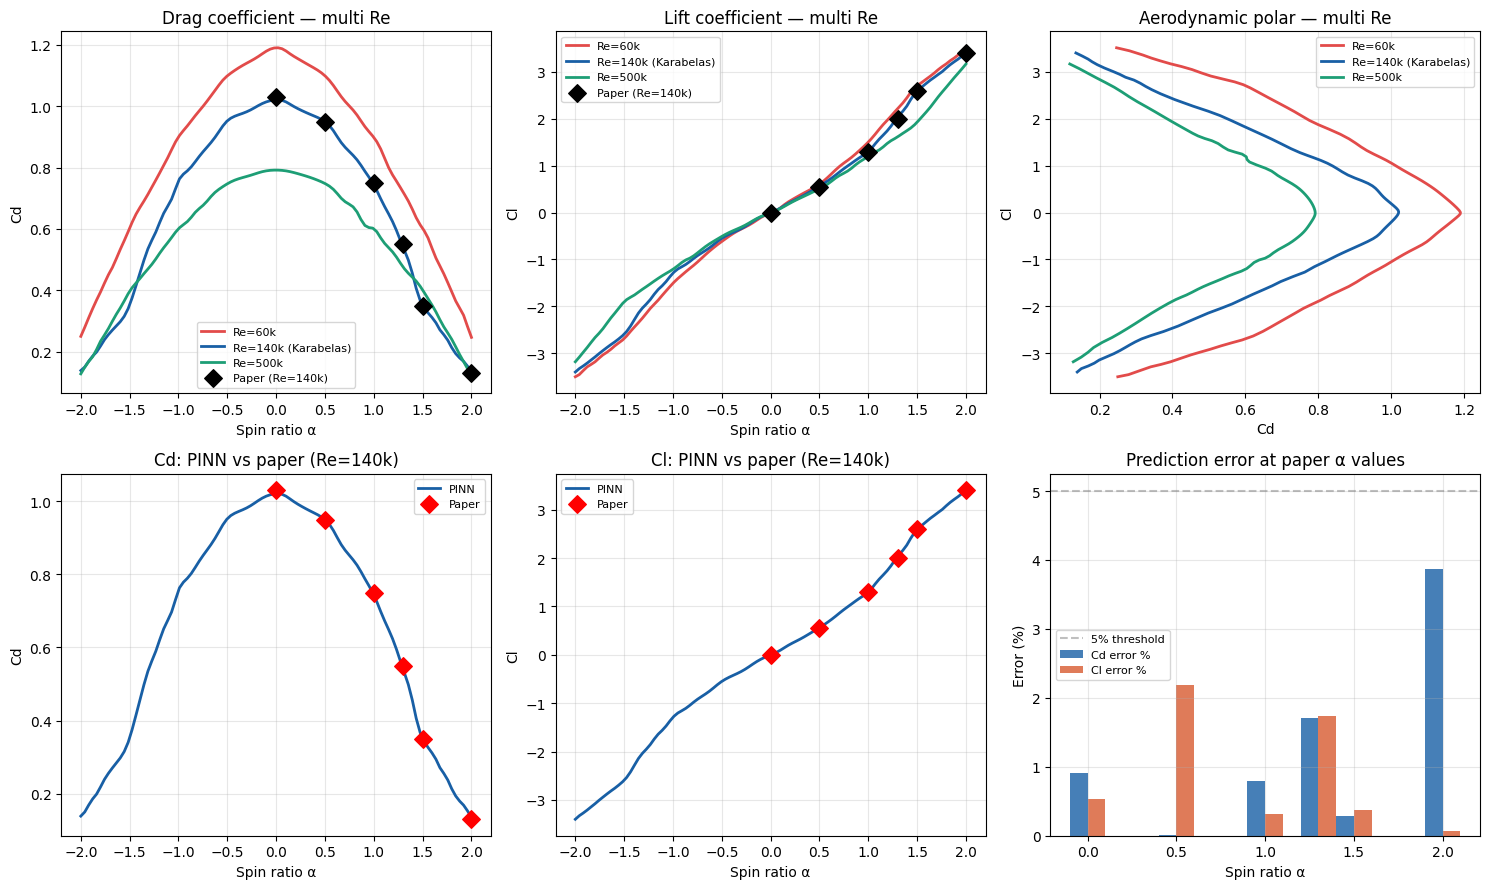

Prediction plots saved.


In [14]:
# Re-extract paper values for Re=140k, as they were overwritten by the loop in the previous cell
paper_alpha = np.array(raw_literature_data['140000']['alpha'])
paper_cd = np.array(raw_literature_data['140000']['Cd'])
paper_cl = np.array(raw_literature_data['140000']['Cl'])

# ============================================================
# CELL 10 — Compare predictions across Reynolds numbers
# ============================================================
# This is the key upgrade: the model can now predict for any Re

alpha_fine = np.linspace(-2, 2, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

re_configs = [
    (60000,  '#E24B4A', 'Re=60k'),
    (140000, '#185FA5', 'Re=140k (Karabelas)'),
    (500000, '#1D9E75', 'Re=500k'),
]

# Row 0: Cd and Cl curves for all Re
for re_val, color, label in re_configs:
    pred = predict(alpha_fine, re_value=re_val)
    axes[0, 0].plot(alpha_fine, pred['Cd_pred'], color=color, linewidth=2, label=label)
    axes[0, 1].plot(alpha_fine, pred['Cl_pred'], color=color, linewidth=2, label=label)
    axes[0, 2].plot(pred['Cd_pred'], pred['Cl_pred'], color=color, linewidth=2, label=label)

# Mark paper values on Re=140k
axes[0, 0].scatter(paper_alpha, paper_cd, s=80, c='black', marker='D', zorder=5, label='Paper (Re=140k)')
axes[0, 1].scatter(paper_alpha, paper_cl, s=80, c='black', marker='D', zorder=5, label='Paper (Re=140k)')

axes[0, 0].set(xlabel='Spin ratio α', ylabel='Cd', title='Drag coefficient — multi Re')
axes[0, 1].set(xlabel='Spin ratio α', ylabel='Cl', title='Lift coefficient — multi Re')
axes[0, 2].set(xlabel='Cd', ylabel='Cl', title='Aerodynamic polar — multi Re')

# Row 1: Detailed comparison at Re=140k vs paper
preds_140k_fine = predict(alpha_fine, re_value=140000)
axes[1, 0].plot(alpha_fine, preds_140k_fine['Cd_pred'], color='#185FA5', linewidth=2, label='PINN')
axes[1, 0].scatter(paper_alpha, paper_cd, s=80, c='red', marker='D', zorder=5, label='Paper')
axes[1, 0].set(xlabel='Spin ratio α', ylabel='Cd', title='Cd: PINN vs paper (Re=140k)')

axes[1, 1].plot(alpha_fine, preds_140k_fine['Cl_pred'], color='#185FA5', linewidth=2, label='PINN')
axes[1, 1].scatter(paper_alpha, paper_cl, s=80, c='red', marker='D', zorder=5, label='Paper')
axes[1, 1].set(xlabel='Spin ratio α', ylabel='Cl', title='Cl: PINN vs paper (Re=140k)')

# Error bars
preds_at_paper = predict(paper_alpha, re_value=140000)
cd_err = np.abs(preds_at_paper['Cd_pred'].values - paper_cd) / np.maximum(paper_cd, 0.05) * 100
cl_err = np.abs(preds_at_paper['Cl_pred'].values - paper_cl) / np.maximum(np.abs(paper_cl), 0.1) * 100

axes[1, 2].bar(paper_alpha - 0.05, cd_err, width=0.1, color='#185FA5', label='Cd error %', alpha=0.8)
axes[1, 2].bar(paper_alpha + 0.05, cl_err, width=0.1, color='#D85A30', label='Cl error %', alpha=0.8)
axes[1, 2].axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='5% threshold')
axes[1, 2].set(xlabel='Spin ratio α', ylabel='Error (%)', title='Prediction error at paper α values')

for ax in axes.flat:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pinn_predictions_multi_re.png', dpi=120, bbox_inches='tight')
plt.show()
print('Prediction plots saved.')